In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import r2_score,root_mean_squared_error
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("dataset/india_housing_prices_sample.csv")


In [4]:
df.sample(5)

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
17623,220857,Karnataka,Mangalore,Locality_110,Villa,1,4766,347.79,0.07,1998,...,27,4,1,High,Yes,No,"Gym, Playground, Clubhouse, Pool",East,Broker,Under_Construction
9256,65785,Haryana,Gurgaon,Locality_87,Villa,3,4304,87.48,0.02,2022,...,3,2,6,High,Yes,No,"Clubhouse, Pool, Garden",West,Broker,Under_Construction
14763,246187,Andhra Pradesh,Vijayawada,Locality_134,Independent House,3,2352,102.50,0.04,1999,...,26,7,2,Medium,No,No,"Garden, Pool, Playground",South,Builder,Ready_to_Move
10202,133840,Haryana,Faridabad,Locality_439,Independent House,5,2229,454.83,0.20,1996,...,29,6,3,Low,No,No,"Garden, Gym, Pool, Clubhouse, Playground",North,Broker,Under_Construction
2786,209275,Karnataka,Mysore,Locality_396,Apartment,5,3111,464.64,0.15,2017,...,8,8,7,Medium,No,Yes,"Pool, Garden, Clubhouse",South,Owner,Under_Construction


In [5]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [6]:
df

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,38684,Haryana,Gurgaon,Locality_123,Independent House,4,692,256.62,0.37,2022,...,3,6,6,Medium,Yes,No,"Playground, Pool",South,Builder,Ready_to_Move
1,64940,Andhra Pradesh,Vishakhapatnam,Locality_74,Apartment,2,3094,86.04,0.03,2015,...,10,3,8,Medium,No,No,"Gym, Clubhouse, Pool, Garden",South,Builder,Under_Construction
2,3955,Madhya Pradesh,Bhopal,Locality_486,Apartment,3,4993,237.86,0.05,1995,...,30,10,1,High,No,No,"Gym, Pool, Playground, Clubhouse, Garden",West,Owner,Ready_to_Move
3,120375,Punjab,Ludhiana,Locality_13,Villa,1,2461,339.41,0.14,2018,...,7,10,5,Low,Yes,No,"Pool, Gym",South,Owner,Under_Construction
4,172862,Haryana,Faridabad,Locality_22,Independent House,2,4535,124.99,0.03,1991,...,34,5,9,Medium,No,Yes,Pool,South,Builder,Under_Construction
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,98085,Gujarat,Ahmedabad,Locality_67,Apartment,4,4675,332.40,0.07,2006,...,19,1,6,High,No,No,"Playground, Gym, Pool",West,Owner,Under_Construction
19996,72705,Delhi,New Delhi,Locality_419,Apartment,3,2298,314.14,0.14,1995,...,30,5,2,Low,No,Yes,"Pool, Garden, Playground",West,Builder,Ready_to_Move
19997,17906,Tamil Nadu,Chennai,Locality_345,Independent House,4,2752,394.21,0.14,2020,...,5,6,3,Medium,No,No,"Clubhouse, Pool",West,Owner,Under_Construction
19998,127303,Uttarakhand,Haridwar,Locality_212,Apartment,2,712,351.41,0.49,2009,...,16,9,5,High,No,No,Playground,South,Builder,Under_Construction


In [7]:
df.columns

Index(['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK',
       'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility',
       'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type',
       'Availability_Status'],
      dtype='object')

In [8]:
df['Furnished_Status'].unique()

array(['Semi-furnished', 'Furnished', 'Unfurnished'], dtype=object)

In [9]:
map_Furnished= {
    'Furnished':2, 
    'Semi-furnished':1,
    'Unfurnished':0
}
df['Furnished_Status']=df['Furnished_Status'].map(map_Furnished)

In [10]:
df['Availability_Status'].unique()

array(['Ready_to_Move', 'Under_Construction'], dtype=object)

In [11]:
map_availability={
    'Ready_to_Move':1, 
    'Under_Construction':0
}
df['Availability_Status']=df['Availability_Status'].map(map_availability)

In [12]:
df['Parking_Space'].unique()

array(['Yes', 'No'], dtype=object)

In [13]:
map_parking={
    'Yes':1,
    'No':0
}
df['Parking_Space']=df['Parking_Space'].map(map_parking)

In [14]:
df['Facing'].unique()

array(['South', 'West', 'North', 'East'], dtype=object)

In [15]:
map_facing = {
    'east':3,
    'west':2,
    'north':1,
    'south':0
}

df['Facing']=df['Facing'].map(map_facing)

In [16]:
df['Owner_Type'].unique()

array(['Builder', 'Owner', 'Broker'], dtype=object)

In [17]:
map_OwnerType={
    'Owner':2,
    'Builder':1,
    'Broker':0
}
df['Owner_Type']=df['Owner_Type'].map(map_OwnerType)

In [18]:
df=df.drop(columns=['ID','State', 'City', 'Locality','Amenities','Facing','Owner_Type','Age_of_Property','Availability_Status'])

In [19]:
df.columns

Index(['Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs',
       'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No',
       'Total_Floors', 'Nearby_Schools', 'Nearby_Hospitals',
       'Public_Transport_Accessibility', 'Parking_Space', 'Security'],
      dtype='object')

In [20]:
df.head(5)

,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security
0,Independent House,4,692,256.62,0.37,2022,1,15,24,6,6,Medium,1,No
1,Apartment,2,3094,86.04,0.03,2015,2,3,18,3,8,Medium,0,No
2,Apartment,3,4993,237.86,0.05,1995,0,19,27,10,1,High,0,No
3,Villa,1,2461,339.41,0.14,2018,1,20,14,10,5,Low,1,No
4,Independent House,2,4535,124.99,0.03,1991,1,25,5,5,9,Medium,0,Yes


In [21]:
df['Public_Transport_Accessibility'].unique()

array(['Medium', 'High', 'Low'], dtype=object)

In [22]:
map_transport={
    'High':2,
    'Medium':1,
    'Low':0
}
df['Public_Transport_Accessibility']=df['Public_Transport_Accessibility'].map(map_transport)

In [23]:
df['Security'].unique()

array(['No', 'Yes'], dtype=object)

In [24]:
map_secure={
    'No':0,
    'Yes':1
}
df['Security']=df['Security'].map(map_secure)

In [25]:
df['total_score'] = df['Parking_Space'] + df['Security'] + df['Public_Transport_Accessibility']
df

,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,total_score
0,Independent House,4,692,256.62,0.37,2022,1,15,24,6,6,1,1,0,2
1,Apartment,2,3094,86.04,0.03,2015,2,3,18,3,8,1,0,0,1
2,Apartment,3,4993,237.86,0.05,1995,0,19,27,10,1,2,0,0,2
3,Villa,1,2461,339.41,0.14,2018,1,20,14,10,5,0,1,0,1
4,Independent House,2,4535,124.99,0.03,1991,1,25,5,5,9,1,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,Apartment,4,4675,332.40,0.07,2006,1,12,19,1,6,2,0,0,2
19996,Apartment,3,2298,314.14,0.14,1995,2,18,15,5,2,0,0,1,1
19997,Independent House,4,2752,394.21,0.14,2020,2,14,29,6,3,1,0,0,1
19998,Apartment,2,712,351.41,0.49,2009,2,3,4,9,5,2,0,0,2


In [26]:
df=df.drop(columns=['Parking_Space','Security','Public_Transport_Accessibility'])

In [27]:
df

,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Nearby_Schools,Nearby_Hospitals,total_score
0,Independent House,4,692,256.62,0.37,2022,1,15,24,6,6,2
1,Apartment,2,3094,86.04,0.03,2015,2,3,18,3,8,1
2,Apartment,3,4993,237.86,0.05,1995,0,19,27,10,1,2
3,Villa,1,2461,339.41,0.14,2018,1,20,14,10,5,1
4,Independent House,2,4535,124.99,0.03,1991,1,25,5,5,9,2
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,Apartment,4,4675,332.40,0.07,2006,1,12,19,1,6,2
19996,Apartment,3,2298,314.14,0.14,1995,2,18,15,5,2,1
19997,Independent House,4,2752,394.21,0.14,2020,2,14,29,6,3,1
19998,Apartment,2,712,351.41,0.49,2009,2,3,4,9,5,2


In [28]:
df.columns

Index(['Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs',
       'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No',
       'Total_Floors', 'Nearby_Schools', 'Nearby_Hospitals', 'total_score'],
      dtype='object')

In [29]:
ohe = OneHotEncoder(sparse_output=False,drop='first')
cat_cols=['Property_Type','Furnished_Status']
encoded_df= ohe.fit_transform(df[cat_cols])

In [30]:
new_encoded = pd.DataFrame(encoded_df,columns=ohe.get_feature_names_out(cat_cols))
new_encoded

,Property_Type_Independent House,Property_Type_Villa,Furnished_Status_1,Furnished_Status_2
0,1.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0
3,0.0,1.0,1.0,0.0
4,1.0,0.0,1.0,0.0
...,...,...,...,...
19995,0.0,0.0,1.0,0.0
19996,0.0,0.0,0.0,1.0
19997,1.0,0.0,0.0,1.0
19998,0.0,0.0,0.0,1.0


In [31]:
df=df.merge(new_encoded,right_index=True,left_index=True)

In [32]:
df=df.drop(columns=['Property_Type','Furnished_Status'])

In [33]:
df.columns

Index(['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Floor_No', 'Total_Floors', 'Nearby_Schools', 'Nearby_Hospitals',
       'total_score', 'Property_Type_Independent House', 'Property_Type_Villa',
       'Furnished_Status_1', 'Furnished_Status_2'],
      dtype='object')

In [34]:
df.head()

,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Nearby_Schools,Nearby_Hospitals,total_score,Property_Type_Independent House,Property_Type_Villa,Furnished_Status_1,Furnished_Status_2
0,4,692,256.62,0.37,2022,15,24,6,6,2,1.0,0.0,1.0,0.0
1,2,3094,86.04,0.03,2015,3,18,3,8,1,0.0,0.0,0.0,1.0
2,3,4993,237.86,0.05,1995,19,27,10,1,2,0.0,0.0,0.0,0.0
3,1,2461,339.41,0.14,2018,20,14,10,5,1,0.0,1.0,1.0,0.0
4,2,4535,124.99,0.03,1991,25,5,5,9,2,1.0,0.0,1.0,0.0


In [35]:
df['age']=2026-df['Year_Built']

In [36]:
df.head()

,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Nearby_Schools,Nearby_Hospitals,total_score,Property_Type_Independent House,Property_Type_Villa,Furnished_Status_1,Furnished_Status_2,age
0,4,692,256.62,0.37,2022,15,24,6,6,2,1.0,0.0,1.0,0.0,4
1,2,3094,86.04,0.03,2015,3,18,3,8,1,0.0,0.0,0.0,1.0,11
2,3,4993,237.86,0.05,1995,19,27,10,1,2,0.0,0.0,0.0,0.0,31
3,1,2461,339.41,0.14,2018,20,14,10,5,1,0.0,1.0,1.0,0.0,8
4,2,4535,124.99,0.03,1991,25,5,5,9,2,1.0,0.0,1.0,0.0,35


In [37]:
df=df.drop(columns='Year_Built')

In [49]:
corr=df.corr(numeric_only=True)

<Axes: >

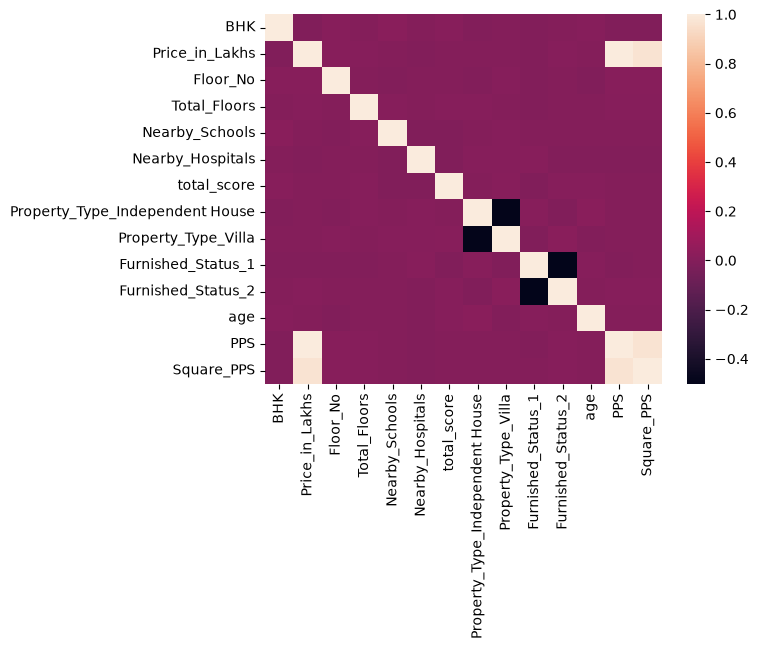

In [50]:
sns.heatmap(corr)

In [39]:
df

,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Floor_No,Total_Floors,Nearby_Schools,Nearby_Hospitals,total_score,Property_Type_Independent House,Property_Type_Villa,Furnished_Status_1,Furnished_Status_2,age
0,4,692,256.62,0.37,15,24,6,6,2,1.0,0.0,1.0,0.0,4
1,2,3094,86.04,0.03,3,18,3,8,1,0.0,0.0,0.0,1.0,11
2,3,4993,237.86,0.05,19,27,10,1,2,0.0,0.0,0.0,0.0,31
3,1,2461,339.41,0.14,20,14,10,5,1,0.0,1.0,1.0,0.0,8
4,2,4535,124.99,0.03,25,5,5,9,2,1.0,0.0,1.0,0.0,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,4,4675,332.40,0.07,12,19,1,6,2,0.0,0.0,1.0,0.0,20
19996,3,2298,314.14,0.14,18,15,5,2,1,0.0,0.0,0.0,1.0,31
19997,4,2752,394.21,0.14,14,29,6,3,1,1.0,0.0,0.0,1.0,6
19998,2,712,351.41,0.49,3,4,9,5,2,0.0,0.0,0.0,1.0,17


In [40]:
df['PPS'] = df['Size_in_SqFt'] * df['Price_per_SqFt']
df['Square_PPS'] = (df['Size_in_SqFt']**2) * (df['Price_per_SqFt']**2)

In [41]:
df=df.drop(columns=['Size_in_SqFt','Price_per_SqFt'])

In [42]:
x=df.drop("Price_in_Lakhs",axis=1)
y=df["Price_in_Lakhs"]

In [43]:
x

,BHK,Floor_No,Total_Floors,Nearby_Schools,Nearby_Hospitals,total_score,Property_Type_Independent House,Property_Type_Villa,Furnished_Status_1,Furnished_Status_2,age,PPS,Square_PPS
0,4,15,24,6,6,2,1.0,0.0,1.0,0.0,4,256.04,65556.4816
1,2,3,18,3,8,1,0.0,0.0,0.0,1.0,11,92.82,8615.5524
2,3,19,27,10,1,2,0.0,0.0,0.0,0.0,31,249.65,62325.1225
3,1,20,14,10,5,1,0.0,1.0,1.0,0.0,8,344.54,118707.8116
4,2,25,5,5,9,2,1.0,0.0,1.0,0.0,35,136.05,18509.6025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,4,12,19,1,6,2,0.0,0.0,1.0,0.0,20,327.25,107092.5625
19996,3,18,15,5,2,1,0.0,0.0,0.0,1.0,31,321.72,103503.7584
19997,4,14,29,6,3,1,1.0,0.0,0.0,1.0,6,385.28,148440.6784
19998,2,3,4,9,5,2,0.0,0.0,0.0,1.0,17,348.88,121717.2544


In [44]:
y=np.log1p(df["Price_in_Lakhs"])
y

0        5.551486
1        4.466368
2        5.475878
3        5.830151
4        4.836203
           ...   
19995    5.809343
19996    5.753017
19997    5.979417
19998    5.864795
19999    5.219112
Name: Price_in_Lakhs, Length: 20000, dtype: float64

In [45]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
model=LinearRegression()

x_train_scaled

array([[-0.71116775, -0.00601505,  1.20445309, ..., -1.27763151,
         0.08686412, -0.18293996],
       [-0.71116775, -0.00601505, -0.17606659, ..., -1.48402672,
         0.74257399,  0.59711859],
       [-0.71116775,  0.10563313,  0.85932317, ...,  0.47672779,
         0.47349952,  0.24903909],
       ...,
       [ 0.7074439 ,  1.22211491,  1.54958302, ...,  1.09591342,
         0.54564882,  0.33855175],
       [ 1.41674973, -0.2293114 , -0.98136974, ...,  0.88951821,
        -1.67909625, -1.13369704],
       [ 1.41674973, -1.34579318, -0.17606659, ...,  1.40550624,
        -1.63396757, -1.13028549]], shape=(16000, 13))

In [46]:
model.fit(x_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
y_pred_log = model.predict(x_test_scaled)

# Convert predictions back to original price scale
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [52]:
# Evaluation metrics
rmse = root_mean_squared_error(y_true, y_pred)
r2_log = r2_score(y_test, y_pred_log)
r2_orig = r2_score(y_true, y_pred)

print(f"R² Score (Log Scale): {r2_log:.4f}")
print(f"R² Score (Original Scale): {r2_orig:.4f}")
print(f"RMSE: {rmse:.2f} Lakhs")

R² Score (Log Scale): 0.9590
R² Score (Original Scale): 0.9563
RMSE: 29.58 Lakhs


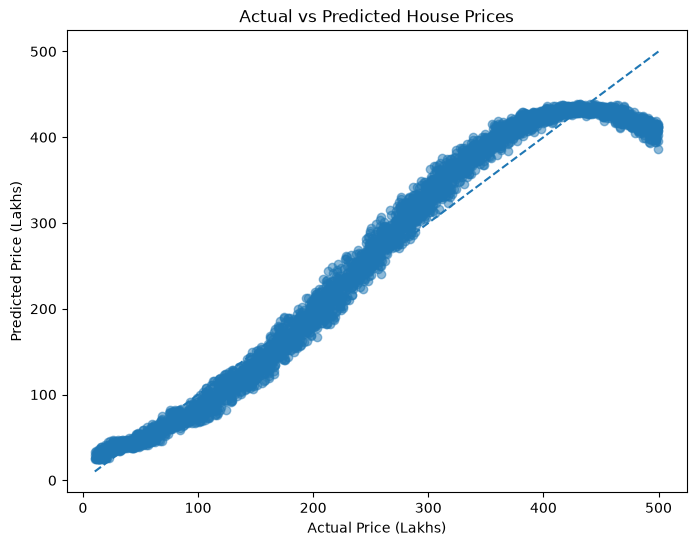

In [53]:
plt.figure(figsize=(8, 6))

plt.scatter(y_true, y_pred, alpha=0.5)

plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    linestyle="--"
)

plt.show()